The previous notebooks built and validated the VaR model. This one answers the question a desk
actually cares about: what does it mean in dollars? We take the final model (the ensemble) and run
it as if a physical desk had held a position through 2024-2026 — looking at the daily dollar risk,
the P&L, what the breaches would have cost, the expected shortfall, and how the model would size
positions. No new data: we treat the out-of-sample test period as a simulated live run.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 100

np.random.seed(42)  
print("Setup OK")

Setup OK


In [2]:
# Load the ensemble VaR (final model) saved from notebook 05
ev = pd.read_pickle("../data/processed/ensemble_var.pkl")

print(f"Shape  : {ev.shape}") 
print(f"Range  : {ev.index.min().date()} → {ev.index.max().date()}")
print(f"Columns: {list(ev.columns)}")
print("\nAll values are in USD/bbl (next-day ΔDFL quantiles + the realized move).\n")
print(ev.head().round(3).to_string())

Shape  : (587, 6)
Range  : 2024-01-02 → 2026-05-05
Columns: ['q01', 'q05', 'q95', 'q99', 'realized', 'regime']

All values are in USD/bbl (next-day ΔDFL quantiles + the realized move).

              q01    q05   q95   q99  realized  regime
date                                                  
2024-01-02 -2.622 -1.875 1.735 2.361    -0.730   1.000
2024-01-03 -2.211 -1.384 1.764 2.664    -0.655   1.000
2024-01-04 -2.347 -1.317 1.854 2.554     1.565   1.000
2024-01-05 -2.274 -1.553 1.642 2.547    -0.285   1.000
2024-01-08 -2.450 -1.554 1.690 2.228     1.610   1.000


  Let's step into the shoes of a physical desk that is long the basis: it has bought 1,000,000 bbl of
  Dated-priced crude and hedged it with futures, so it is effectively long 1 Mbbl of DFL. Its daily
  P&L is just the position times the day's DFL move: P&L = 1,000,000 × ΔDFL. Being long, it loses
  money when the DFL falls (ΔDFL below 0), so the risk that matters is the downside — the q01 (99% VaR)
  and q05 (95% VaR) quantiles.

In [3]:
# Position: long 1,000,000 bbl of the DFL (physical desk: long Dated, hedged with futures)
POSITION_BBL = 1_000_000

# Dollar VaR = position size × the downside quantile (q01 = 99%, q05 = 95%).
# q01/q05 are negative (downside moves), so we flip the sign to report a positive loss figure.
dollar = pd.DataFrame(index=ev.index)
dollar["var95"] = -POSITION_BBL * ev["q05"]       # 1-day 95% VaR (USD)
dollar["var99"] = -POSITION_BBL * ev["q01"]       # 1-day 99% VaR (USD)
dollar["pnl"]   =  POSITION_BBL * ev["realized"]  # realized daily P&L (USD)

print(f"Position: long {POSITION_BBL:,} bbl of DFL\n")
print("1-day VaR (USD) over the test period:")
print(f"  95% VaR : mean ${dollar['var95'].mean():,.0f}   min ${dollar['var95'].min():,.0f}   max ${dollar['var95'].max():,.0f}")
print(f"  99% VaR : mean ${dollar['var99'].mean():,.0f}   min ${dollar['var99'].min():,.0f}   max ${dollar['var99'].max():,.0f}")
print(f"\nWorst single-day loss actually realized: ${dollar['pnl'].min():,.0f}  ({dollar['pnl'].idxmin().date()})")

Position: long 1,000,000 bbl of DFL

1-day VaR (USD) over the test period:
  95% VaR : mean $1,662,095   min $655,780   max $6,643,436
  99% VaR : mean $2,662,281   min $1,611,990   max $10,675,186

Worst single-day loss actually realized: $-8,310,000  (2026-04-14)


  On a normal day the desk's 1-day 99% VaR is around 2.7 million dollars — the model saying it's 99%
  confident the position won't lose more than that overnight. But the headline isn't the average, it's
  the range: the 99% VaR sits near 1.6M in calm 2024-2025 and balloons to 10.7M during the April 2026
  crisis — more than a 6x jump. That is exactly what a conditional VaR buys you: it tells the desk in
  real time that its risk has exploded, while a flat Gaussian VaR would still be quoting ~2M and miss
  it entirely.
  
  And the worst day did cost 8.3M (2026-04-14): far beyond the calm-period VaR, but well within the
  crisis VaR the model was quoting by then. So the loss was framed as plausible, not a total surprise —
  the model had already widened to expect moves of that size.

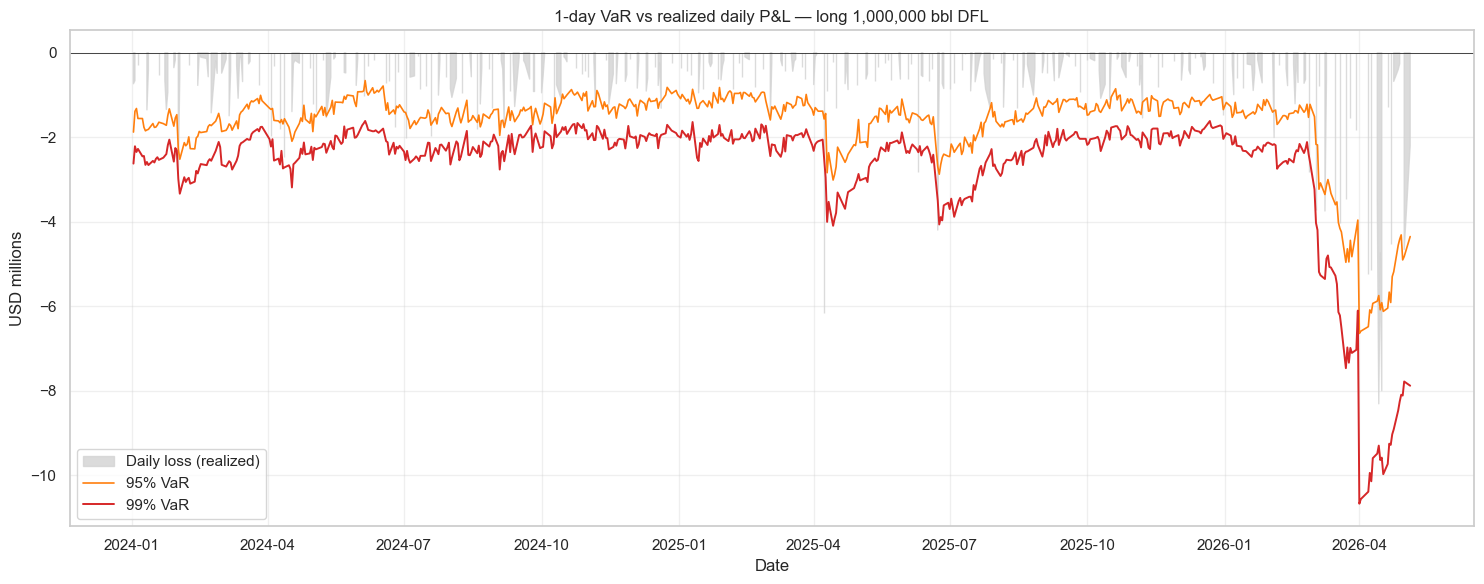

In [4]:
# How the dollar VaR breathes vs the realized daily P&L
fig, ax = plt.subplots(figsize=(15, 6))

# Realized daily losses (gray fill below zero)
ax.fill_between(dollar.index, dollar["pnl"] / 1e6, 0, where=dollar["pnl"] < 0,
                color="lightgray", alpha=0.8, label="Daily loss (realized)")

# VaR thresholds, drawn as negative (a loss line)
ax.plot(dollar.index, -dollar["var95"] / 1e6, color="#ff7f0e", lw=1.2, label="95% VaR")
ax.plot(dollar.index, -dollar["var99"] / 1e6, color="#d62728", lw=1.4, label="99% VaR")

ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("USD millions")
ax.set_xlabel("Date")
ax.set_title(f"1-day VaR vs realized daily P&L — long {POSITION_BBL:,} bbl DFL")
ax.legend(loc="lower left")
ax.grid(alpha=0.3)  
plt.tight_layout()
plt.show()

In [7]:
loss = -dollar["pnl"]      # positive number = a loss (USD)

print("Historical VaR vs Expected Shortfall (realized P&L over the test period):\n")
print(f"{'Confidence':<12}{'VaR (USD)':>16}{'ES (USD)':>16}{'ES / VaR':>10}")
print("-" * 54)
for conf in [0.95, 0.99]:
    var = loss.quantile(conf)            # the VaR threshold
    es  = loss[loss >= var].mean()       # average loss beyond it = ES
    print(f"{conf:>6.0%}{'':<6}{var:>16,.0f}{es:>16,.0f}{es/var:>10.2f}")

Historical VaR vs Expected Shortfall (realized P&L over the test period):

Confidence         VaR (USD)        ES (USD)  ES / VaR
------------------------------------------------------
   95%             1,550,500       3,483,500      2.25
   99%             4,666,200       6,261,667      1.34


The gap between VaR and ES is the whole point, and it's brutal here. At 95%, the VaR says the desk
won't lose more than 1.55M on 95% of days — but on the 5% of days it does break, the average loss is
3.48M, more than double (ES/VaR = 2.25). The threshold massively understates how bad the bad days
actually are. At 99% the gap is smaller (1.34x) simply because you're already deep in the tail.

That 2.25x is the fat tail of the DFL (kurtosis +62) showing up in dollars: beyond the VaR line, the
losses don't taper off gently — they jump. A desk managing only to its 95% VaR would size its capital
to ~1.5M and get hit with 3.5M when it matters. This is exactly why Basel III / FRTB replaced VaR with
Expected Shortfall: for fat-tailed exposures, the VaR threshold hides the severity, and ES is the
number that actually tells you how much capital to hold against the tail.

(Note: these are historical figures — the VaR and ES of the realized P&L over the whole test period —
a different lens from the model's day-by-day VaR earlier. Here the point is the VaR-to-ES gap, i.e.
the shape of the tail, not the absolute level.)

Risk budget: $100,000,000  (max 1-day 99% VaR)

Allowable position over the test period:
  mean        :   43,155,783 bbl
  calm  (max) :   62,035,113 bbl
  crisis (min):    9,367,518 bbl

  → allowable size shrinks 6.6x from calm to crisis


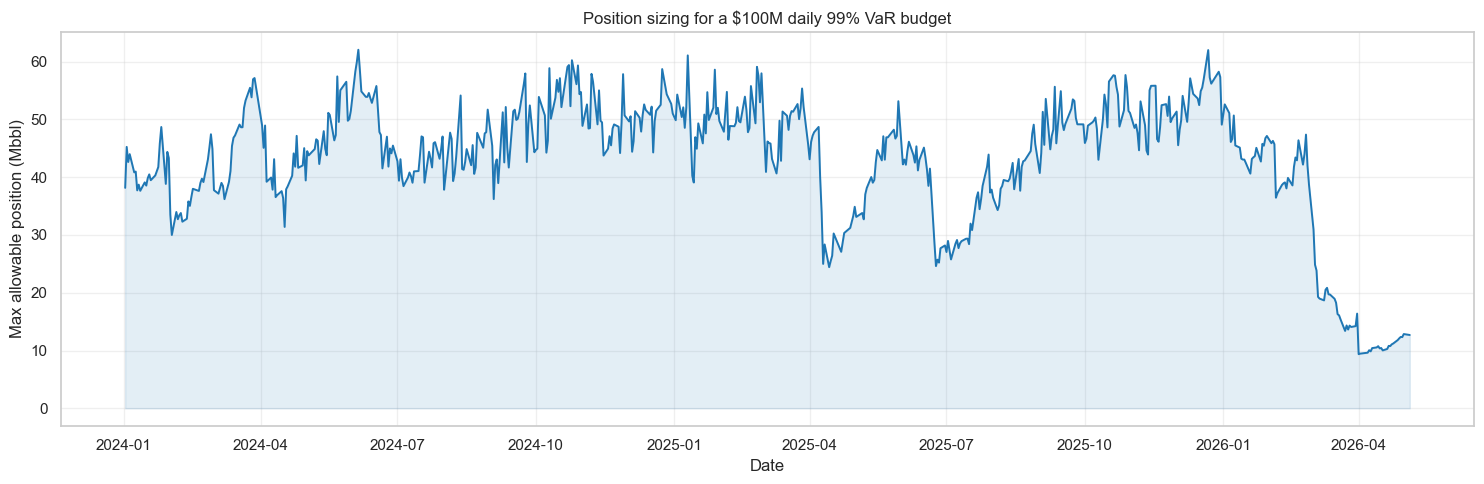

In [9]:
RISK_BUDGET = 100_000_000        # max 1-day 99% VaR the desk may run (USD)

var_per_bbl  = -ev["q01"]                    # 99% downside VaR per bbl (USD/bbl, positive)
max_position = RISK_BUDGET / var_per_bbl     # allowable position size (bbl)

print(f"Risk budget: ${RISK_BUDGET:,.0f}  (max 1-day 99% VaR)\n")
print("Allowable position over the test period:")
print(f"  mean        : {max_position.mean():>12,.0f} bbl")
print(f"  calm  (max) : {max_position.max():>12,.0f} bbl")
print(f"  crisis (min): {max_position.min():>12,.0f} bbl")
print(f"\n  → allowable size shrinks {max_position.max()/max_position.min():.1f}x from calm to crisis")

# Plot
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(max_position.index, max_position / 1e6, color="#1f77b4", lw=1.4)
ax.fill_between(max_position.index, max_position / 1e6, 0, color="#1f77b4", alpha=0.12)
ax.set_ylabel("Max allowable position (Mbbl)")
ax.set_xlabel("Date")
ax.set_title(f"Position sizing for a ${RISK_BUDGET/1e6:.0f}M daily 99% VaR budget")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

This is the same model, used as a position limit instead of a risk report. For a 20M daily 99% VaR
budget, the desk could run about 12 Mbbl of DFL in calm markets — but the moment April 2026 hits and
the per-bbl risk explodes, the allowable size collapses to under 2 Mbbl, a 6-7x cut. The model does
this automatically: as it widens its bands, it forces the desk to shrink the book exactly when the
market turns dangerous, with no human having to guess. That is the practical payoff of a VaR that
breathes — it isn't just a number to report, it's a live position limit that tightens itself in a
crisis.

## Wrapping up notebook 06

This notebook turned the model from a statistics object into a desk tool. On a 1 Mbbl long-DFL
position, the 1-day 99% VaR runs around 2.7M in calm markets and balloons past 10M in the April 2026
crisis — the risk number breathes with conditions, where a flat VaR would have stayed frozen near 2M
and missed it. Expected Shortfall showed the tail is even worse than the threshold suggests (the 95%
loss averages 2.25x its VaR when it breaks), which is exactly why ES is the regulatory standard for
fat-tailed exposures like this one. And run in reverse, the model becomes a self-tightening position
limit: a fixed risk budget allows a large book in calm and forces a 6-7x cut in the crisis,
automatically.

The takeaway: a conditional VaR isn't just more accurate on a backtest — operationally it does things
a flat VaR can't. It sizes risk in real dollars, quantifies the tail, and enforces de-risking exactly
when it matters. That is what makes the whole regime-conditional approach worth the effort.